In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from datetime import datetime
from scipy import stats
%matplotlib inline
warnings.filterwarnings('ignore')

In [2]:
BASE_DIR = "../"
DATA_PATH = os.path.join(BASE_DIR, "data", "cancer_data_eng.csv")
IMG_DIR = os.path.join(BASE_DIR, "img")
RESULTS_DIR = os.path.join(BASE_DIR, "results")

os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# ============================================================================
# 0. 数据加载
# ============================================================================
print("=" * 70)
print("案例教程 1: 数据探索分析 (EDA)")
print("=" * 70)

print("\n[0] 加载数据...")
df = pd.read_csv(DATA_PATH, low_memory=False, encoding='latin-1')
print(f"    原始数据集形状: {df.shape}")

案例教程 1: 数据探索分析 (EDA)

[0] 加载数据...
    原始数据集形状: (1778176, 38)


# 处理 Status.Vital (目标变量) 的缺失值

In [3]:
n_before = len(df)
df = df.dropna(subset=['Status.Vital']).reset_index(drop=True)
n_after = len(df)
print(f"    删除 Status.Vital 缺失样本: {n_before:,} → {n_after:,} (删除 {n_before - n_after:,} 条, {(n_before - n_after) / n_before * 100:.2f}%)")

# 创建目标变量: VIVO=1 (alive), MORTO=0 (dead)
df['target'] = (df['Status.Vital'] == 'VIVO').astype(int)

print(f"    处理后数据集形状: {df.shape}")
print(f"    内存占用: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


    删除 Status.Vital 缺失样本: 1,778,176 → 209,758 (删除 1,568,418 条, 88.20%)
    处理后数据集形状: (209758, 39)
    内存占用: 360.23 MB


# 内容 1: 数据概况

In [4]:
print("\n" + "=" * 70)
print("内容 1: 数据概况")
print("=" * 70)

n_samples = len(df)
n_features = df.shape[1]
print(f"\n  ▶ 样本数量 (Number of samples): {n_samples:,}")
print(f"  ▶ 特征数量 (Number of features): {n_features}")
print(f"  ▶ 其中包含 {n_features - 1} 个原始特征 + 1 个目标变量 (target)")

# 标签分布
target_counts = df['target'].value_counts()
target_props = df['target'].value_counts(normalize=True) * 100

print(f"\n  ▶ 标签分布 (Target Distribution):")
print(f"      存活 (VIVO = 1): {target_counts.get(1, 0):>10,}  ({target_props.get(1, 0):.2f}%)")
print(f"      死亡 (MORTO = 0): {target_counts.get(0, 0):>10,}  ({target_props.get(0, 0):.2f}%)")

# 平衡性判断
ratio = target_props.get(1, 0) / target_props.get(0, 0)
if 0.8 <= ratio <= 1.2:
    balance_verdict = "数据基本平衡 (Balanced)"
elif 0.5 <= ratio < 0.8 or 1.2 < ratio <= 2.0:
    balance_verdict = "数据轻度不平衡 (Mildly Imbalanced)"
else:
    balance_verdict = "数据严重不平衡 (Severely Imbalanced)"

print(f"\n  ▶ 平衡性判断 (Balance Assessment): {balance_verdict}")
print(f"     存活/死亡 比例 = {ratio:.3f}")


内容 1: 数据概况

  ▶ 样本数量 (Number of samples): 209,758
  ▶ 特征数量 (Number of features): 39
  ▶ 其中包含 38 个原始特征 + 1 个目标变量 (target)

  ▶ 标签分布 (Target Distribution):
      存活 (VIVO = 1):     85,896  (40.95%)
      死亡 (MORTO = 0):    123,862  (59.05%)

  ▶ 平衡性判断 (Balance Assessment): 数据轻度不平衡 (Mildly Imbalanced)
     存活/死亡 比例 = 0.693


  [图] 01_target_distribution.png → 标签分布图已保存


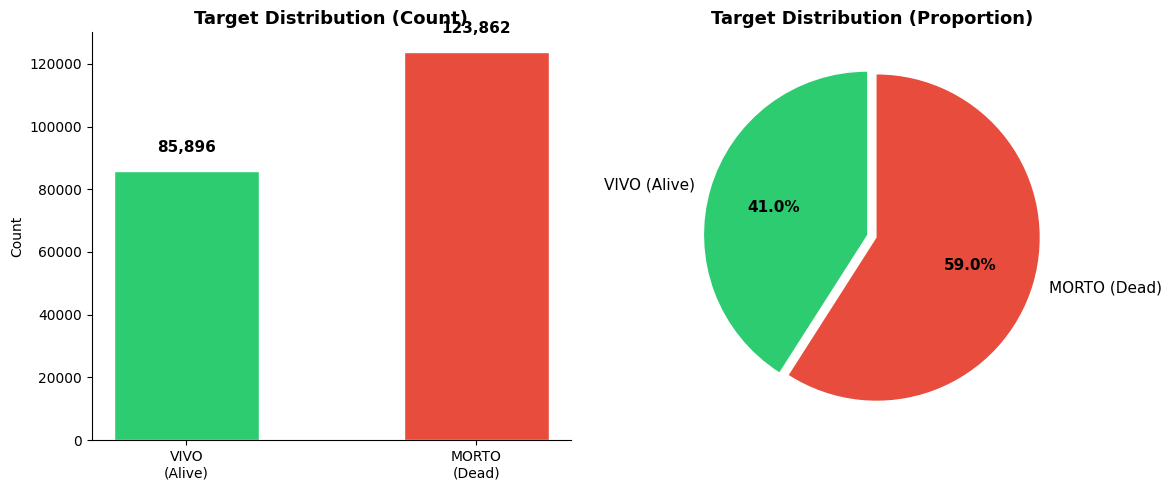

In [5]:

# --- 绘制标签分布图 ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#2ecc71', '#e74c3c']
labels_bar = ['VIVO\n(Alive)', 'MORTO\n(Dead)']

# 条形图
bars = axes[0].bar(labels_bar, [target_counts.get(1, 0), target_counts.get(0, 0)],
                    color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, [target_counts.get(1, 0), target_counts.get(0, 0)]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5000,
                f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Target Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# 饼图
wedges, texts, autotexts = axes[1].pie(
    [target_counts.get(1, 0), target_counts.get(0, 0)],
    labels=['VIVO (Alive)', 'MORTO (Dead)'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    explode=(0.03, 0.03),
    textprops={'fontsize': 11}
)
for autotext in autotexts:
    autotext.set_fontweight('bold')
axes[1].set_title('Target Distribution (Proportion)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "01_target_distribution.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 01_target_distribution.png → 标签分布图已保存")


# 内容 2: 缺失值分析

In [6]:
print("\n" + "=" * 70)
print("内容 2: 缺失值分析")
print("=" * 70)

# 计算各列缺失比例
missing_series = df.isnull().sum()
missing_pct = (missing_series / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing_series.index,
    'Missing_Count': missing_series.values,
    'Missing_Pct': missing_pct.values
}).sort_values('Missing_Pct', ascending=False)

# 只显示缺失 > 0 的列
missing_nonzero = missing_df[missing_df['Missing_Pct'] > 0]

print(f"\n  ▶ 缺失值概况:")
print(f"      存在缺失值的列数: {len(missing_nonzero)} / {df.shape[1]}")
print(f"      完全完整的列数:   {df.shape[1] - len(missing_nonzero)} / {df.shape[1]}")
print(f"\n  ▶ 各列缺失比例 (Top 20):")
print(f"     {'列名':<35} {'缺失数':>10} {'缺失%':>8}")
print(f"     {'-'*35} {'-'*10} {'-'*8}")
for _, row in missing_nonzero.head(20).iterrows():
    print(f"     {row['Column']:<35} {int(row['Missing_Count']):>10,} {row['Missing_Pct']:>7.2f}%")

# 缺失值分档统计
def missing_category(pct):
    if pct == 0:
        return "无缺失"
    elif pct < 5:
        return "轻度 (< 5%)"
    elif pct < 20:
        return "中度 (5%-20%)"
    elif pct < 50:
        return "高度 (20%-50%)"
    else:
        return "严重 (≥ 50%)"

missing_df['Category'] = missing_df['Missing_Pct'].apply(missing_category)
cat_counts = missing_df['Category'].value_counts()

print(f"\n  ▶ 缺失程度分布:")
for cat in ["无缺失", "轻度 (< 5%)", "中度 (5%-20%)", "高度 (20%-50%)", "严重 (≥ 50%)"]:
    count = cat_counts.get(cat, 0)
    if count > 0:
        print(f"      {cat}: {count} 列")


内容 2: 缺失值分析

  ▶ 缺失值概况:
      存在缺失值的列数: 24 / 39
      完全完整的列数:   15 / 39

  ▶ 各列缺失比例 (Top 20):
     列名                                         缺失数      缺失%
     ----------------------------------- ---------- --------
     Child.Illness.Code                     207,000   98.69%
     Child.Illness.Description              207,000   98.69%
     Code.of.Disease.Adult.Young.           205,607   98.02%
     Youth.Adult.Illness.Description        205,607   98.02%
     Distant.metastasis                     199,214   94.97%
     Naturality                             167,547   79.88%
     TNM                                    161,825   77.15%
     Statement                              160,088   76.32%
     Extension                              127,063   60.58%
     Naturality.State                       123,036   58.66%
     Laterality                             104,136   49.65%
     Type.of.Death                           89,313   42.58%
     Date.of.Death                           85,23

  [图] 02a_missing_percentage.png → 缺失比例图已保存
  [图] 02b_missing_pattern.png → 缺失模式热力图已保存
  [图] 02c_missing_correlation.png → 缺失相关性热力图已保存


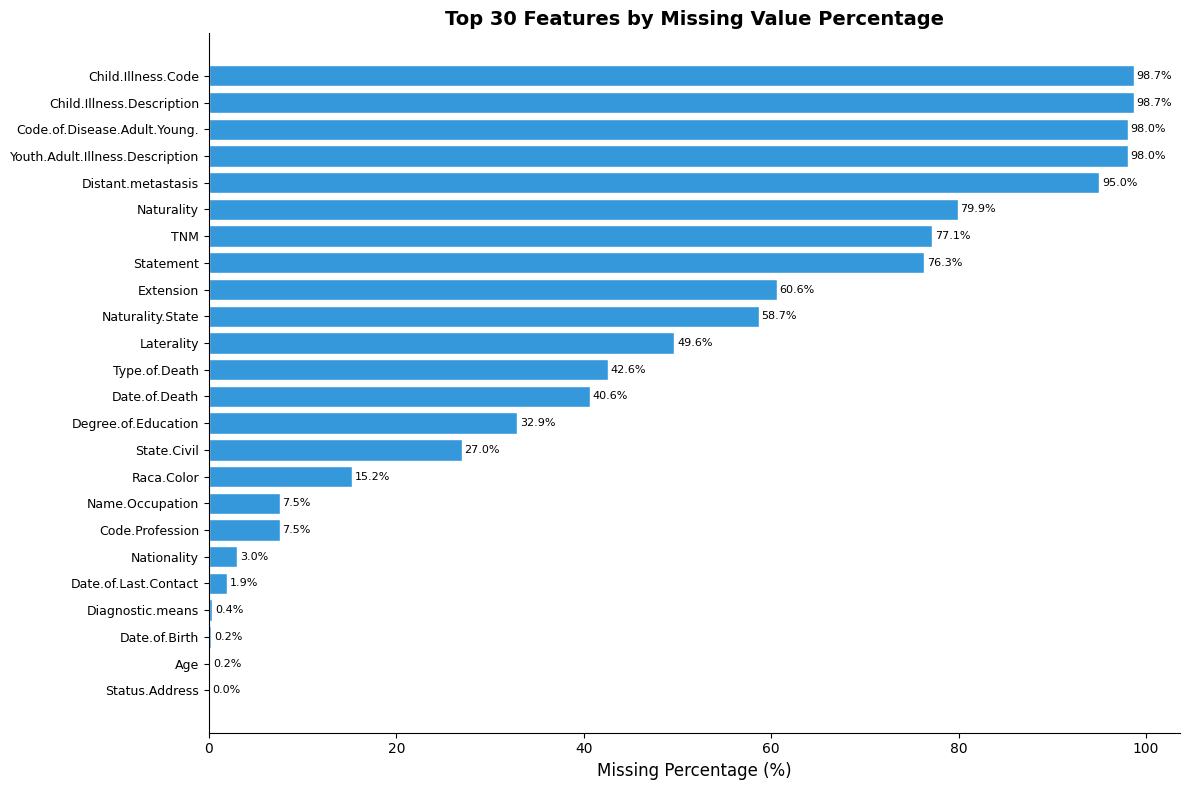

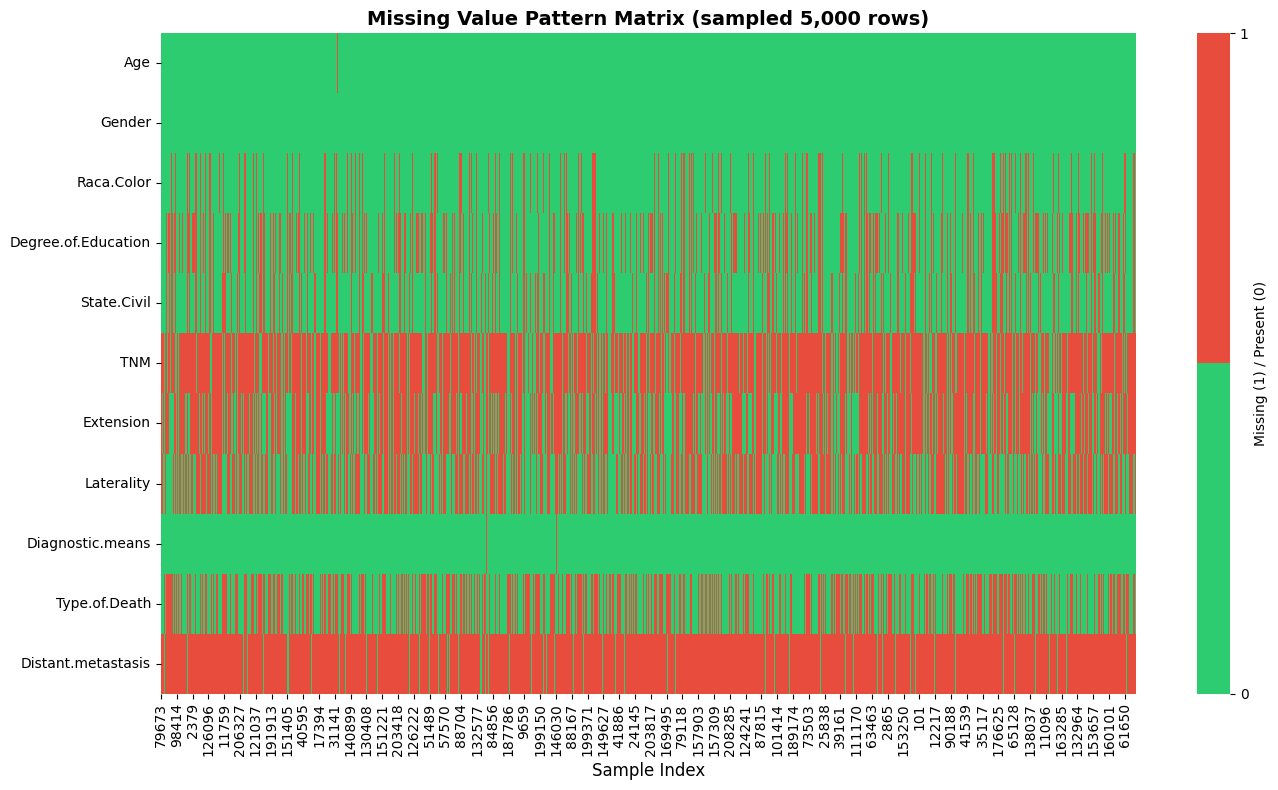

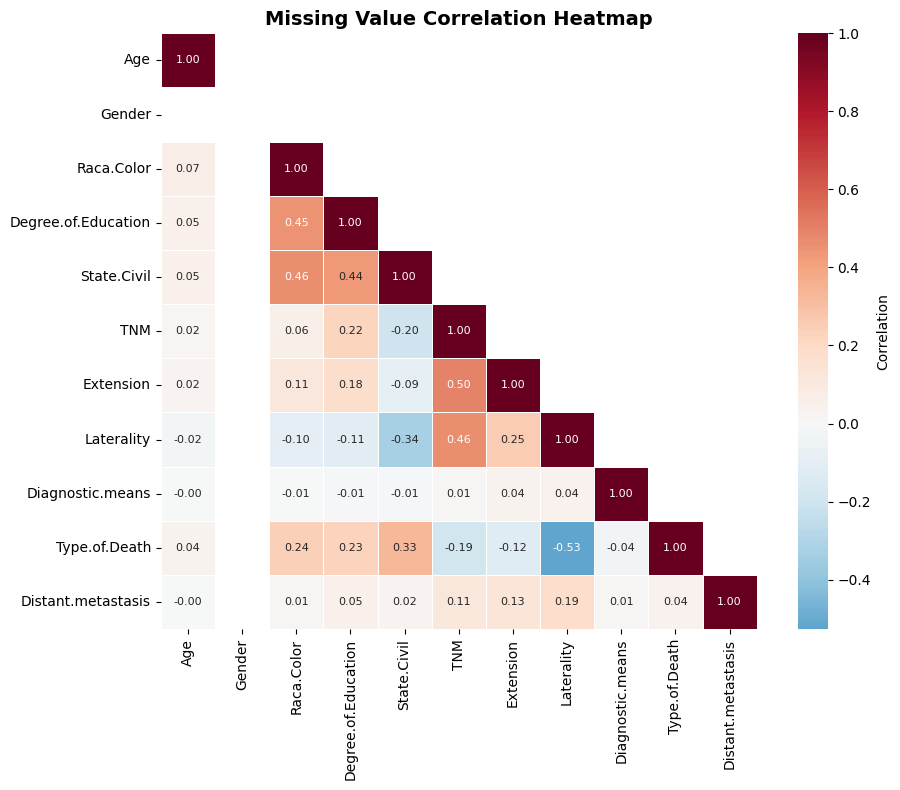

In [7]:

# 图 2a: 缺失比例条形图 (Top 30)
plot_missing = missing_nonzero.head(30)
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(range(len(plot_missing)), plot_missing['Missing_Pct'].values, color='#3498db', edgecolor='white')
ax.set_yticks(range(len(plot_missing)))
ax.set_yticklabels(plot_missing['Column'].values, fontsize=9)
ax.set_xlabel('Missing Percentage (%)', fontsize=12)
ax.set_title('Top 30 Features by Missing Value Percentage', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 添加数值标签
for bar, pct in zip(bars, plot_missing['Missing_Pct'].values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{pct:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "02a_missing_percentage.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 02a_missing_percentage.png → 缺失比例图已保存")

# 图 2b: 缺失矩阵热力图 (选取关键列)
key_cols_candidates = ['Age', 'Gender', 'Raca.Color', 'Degree.of.Education',
                       'State.Civil', 'TNM', 'Extension', 'Laterality',
                       'Diagnostic.means', 'Type.of.Death', 'Distant.metastasis']
key_cols = [c for c in key_cols_candidates if c in df.columns]
missing_matrix = df[key_cols].isnull().astype(int)

# 如果数据太大，抽样显示
sample_size = min(5000, len(df))
if len(df) > sample_size:
    np.random.seed(42)
    sample_idx = np.random.choice(len(df), sample_size, replace=False)
    missing_matrix_sample = missing_matrix.iloc[sample_idx]
else:
    missing_matrix_sample = missing_matrix

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(missing_matrix_sample.T, cmap=['#2ecc71', '#e74c3c'],
            cbar_kws={'label': 'Missing (1) / Present (0)', 'ticks': [0, 1]},
            ax=ax, linewidths=0)
ax.set_xlabel('Sample Index', fontsize=12)
ax.set_title('Missing Value Pattern Matrix (sampled 5,000 rows)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "02b_missing_pattern.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 02b_missing_pattern.png → 缺失模式热力图已保存")

# 图 2c: 缺失值相关性热力图
missing_corr = missing_matrix.corr()
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(missing_corr, dtype=bool), k=1)
sns.heatmap(missing_corr, mask=mask, cmap='RdBu_r', center=0,
            annot=True, fmt='.2f', square=True,
            linewidths=0.5, cbar_kws={'label': 'Correlation'},
            ax=ax, annot_kws={'fontsize': 8})
ax.set_title('Missing Value Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "02c_missing_correlation.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 02c_missing_correlation.png → 缺失相关性热力图已保存")


# 内容 3: 分布分析

In [8]:
print("\n" + "=" * 70)
print("内容 3: 分布分析")
print("=" * 70)

# 选取数值型特征
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# 排除目标变量和 ID 列
exclude_cols = ['target', 'Patient.Code']
numeric_features = [c for c in numeric_cols if c not in exclude_cols]

print(f"\n  ▶ 数值特征列表: {numeric_features}")

# 对每个数值特征进行正态性检验和分布分析
dist_results = []
for col in numeric_features:
    # 丢弃缺失值
    data = df[col].dropna()

    if len(data) < 50:
        continue

    # 基本统计量
    mean_val = data.mean()
    median_val = data.median()
    std_val = data.std()
    skewness = data.skew()
    kurtosis_val = data.kurtosis()

    # 正态性判断: 偏度绝对值 > 1 视为偏态
    if abs(skewness) < 0.5:
        dist_type = "近似正态 (Approx. Normal)"
    elif abs(skewness) < 1:
        dist_type = "轻度偏态 (Mildly Skewed)"
    else:
        dist_type = "显著偏态 (Highly Skewed)"

    dist_results.append({
        'Feature': col,
        'Count': len(data),
        'Mean': mean_val,
        'Median': median_val,
        'Std': std_val,
        'Skewness': skewness,
        'Kurtosis': kurtosis_val,
        'Distribution': dist_type
    })

dist_df = pd.DataFrame(dist_results)
print(f"\n  ▶ 各数值特征分布类型:")
print(f"     {'特征':<25} {'样本量':>8} {'均值':>10} {'中位数':>10} {'偏度':>8} {'分布类型':<22}")
print(f"     {'-'*25} {'-'*8} {'-'*10} {'-'*10} {'-'*8} {'-'*22}")
for _, row in dist_df.iterrows():
    print(f"     {row['Feature']:<25} {int(row['Count']):>8,} {row['Mean']:>10.2f} {row['Median']:>10.2f} {row['Skewness']:>8.3f} {row['Distribution']:<22}")



内容 3: 分布分析

  ▶ 数值特征列表: ['Age', 'Code.Profession', 'Code.of.Morphology', 'year']

  ▶ 各数值特征分布类型:
     特征                             样本量         均值        中位数       偏度 分布类型                  
     ------------------------- -------- ---------- ---------- -------- ----------------------
     Age                        209,443      63.79      65.00   -0.683 轻度偏态 (Mildly Skewed)  
     Code.Profession            193,966     218.34       0.00    0.940 轻度偏态 (Mildly Skewed)  
     Code.of.Morphology         209,758   82428.77   80903.00    2.634 显著偏态 (Highly Skewed)  
     year                       209,758    2012.24    2013.00   -1.004 显著偏态 (Highly Skewed)  


  [图] 03a_distribution_hist_kde.png → 分布直方图+KDE已保存
  [图] 03b_qq_plot.png → Q-Q图已保存
  [图] 03c_age_by_target_boxplot.png → 按目标分组的年龄箱线图已保存


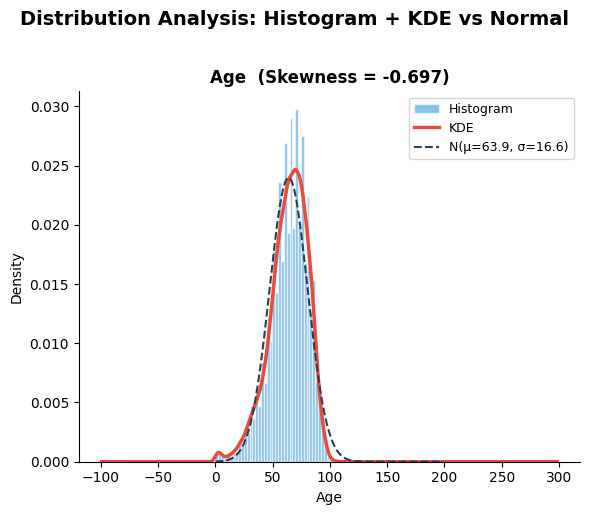

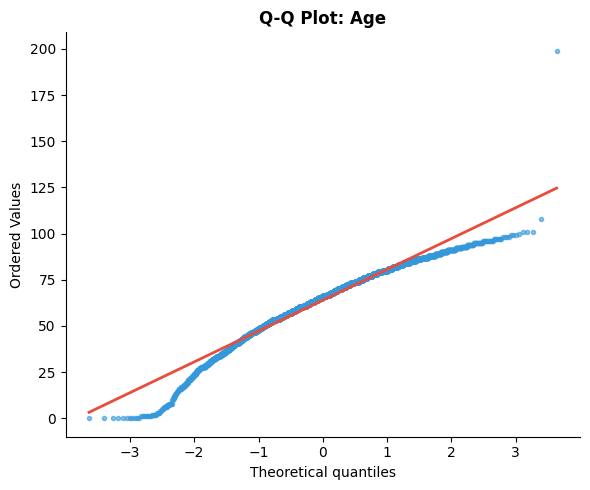

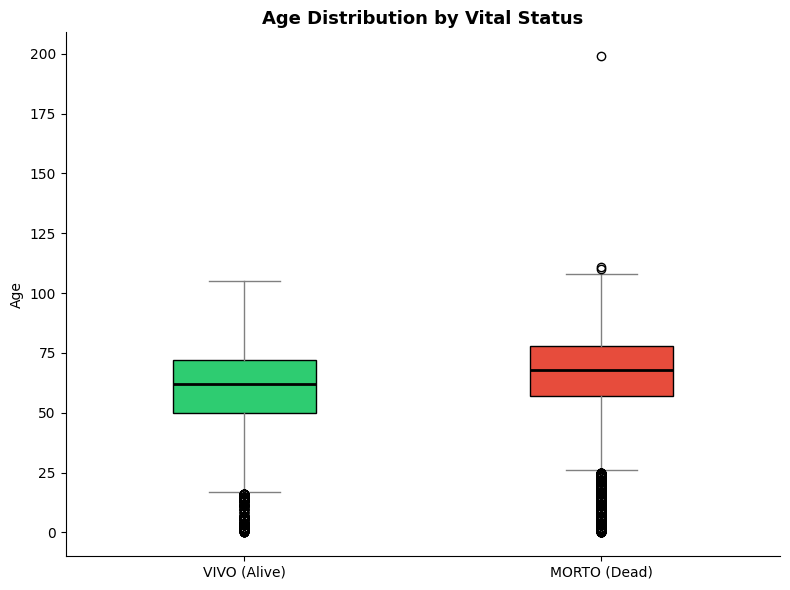

In [9]:
# 图 3a: 核密度 + 直方图 (选取关键数值特征)
plot_features = ['Age'] if 'Age' in numeric_features else numeric_features[:2]
plot_features = [f for f in plot_features if f in df.columns]

fig, axes = plt.subplots(1, len(plot_features), figsize=(6 * len(plot_features), 5))
if len(plot_features) == 1:
    axes = [axes]

for ax, col in zip(axes, plot_features):
    data = df[col].dropna()
    # 如果数据太大，抽样
    if len(data) > 50000:
        data_sample = data.sample(50000, random_state=42)
    else:
        data_sample = data

    ax.hist(data_sample, bins=80, density=True, alpha=0.6,
            color='#3498db', edgecolor='white', label='Histogram')
    # 核密度估计
    data_sample.plot.kde(ax=ax, color='#e74c3c', linewidth=2.5, label='KDE')
    # 正态分布曲线 (用数据的均值和标准差)
    x_range = np.linspace(data_sample.min(), data_sample.max(), 1000)
    normal_pdf = (1 / (data_sample.std() * np.sqrt(2 * np.pi))) * \
                 np.exp(-0.5 * ((x_range - data_sample.mean()) / data_sample.std()) ** 2)
    ax.plot(x_range, normal_pdf, '--', color='#2c3e50', linewidth=1.5,
            label=f'N(μ={data_sample.mean():.1f}, σ={data_sample.std():.1f})')

    skew_val = data_sample.skew()
    ax.set_title(f'{col}  (Skewness = {skew_val:.3f})', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Distribution Analysis: Histogram + KDE vs Normal', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "03a_distribution_hist_kde.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 03a_distribution_hist_kde.png → 分布直方图+KDE已保存")

# 图 3b: Q-Q 图 (用于判断正态性)
fig, axes = plt.subplots(1, len(plot_features), figsize=(6 * len(plot_features), 5))
if len(plot_features) == 1:
    axes = [axes]

for ax, col in zip(axes, plot_features):
    data = df[col].dropna()
    if len(data) > 5000:
        data_qq = data.sample(5000, random_state=42)
    else:
        data_qq = data

    stats.probplot(data_qq, dist="norm", plot=ax)
    ax.get_lines()[0].set_markerfacecolor('#3498db')
    ax.get_lines()[0].set_markeredgecolor('#3498db')
    ax.get_lines()[0].set_markersize(3)
    ax.get_lines()[0].set_alpha(0.6)
    ax.get_lines()[1].set_color('#e74c3c')
    ax.get_lines()[1].set_linewidth(2)
    ax.set_title(f'Q-Q Plot: {col}', fontsize=12, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "03b_qq_plot.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 03b_qq_plot.png → Q-Q图已保存")

# 图 3c: 箱线图 — 按目标分组的 Age 分布
if 'Age' in df.columns:
    fig, ax = plt.subplots(figsize=(8, 6))

    age_data = df[['Age', 'target']].dropna()
    if len(age_data) > 50000:
        age_data = age_data.sample(50000, random_state=42)

    bp = ax.boxplot([age_data.loc[age_data['target'] == 1, 'Age'].values,
                     age_data.loc[age_data['target'] == 0, 'Age'].values],
                    tick_labels=['VIVO (Alive)', 'MORTO (Dead)'],
                    patch_artist=True,
                    widths=0.4)

    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    for whisker in bp['whiskers']:
        whisker.set_color('gray')
    for cap in bp['caps']:
        cap.set_color('gray')
    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(2)

    ax.set_title('Age Distribution by Vital Status', fontsize=13, fontweight='bold')
    ax.set_ylabel('Age')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(os.path.join(IMG_DIR, "03c_age_by_target_boxplot.png"), dpi=150, bbox_inches='tight')
    # plt.close()
    print("  [图] 03c_age_by_target_boxplot.png → 按目标分组的年龄箱线图已保存")


# 内容 4: 离群值分析

In [10]:
print("\n" + "=" * 70)
print("内容 4: 离群值分析")
print("=" * 70)

outlier_features = [f for f in numeric_features if f in df.columns]
outlier_results = []

for col in outlier_features:
    data = df[col].dropna()

    if len(data) < 50:
        continue

    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    lower_iqr = q1 - 1.5 * iqr
    upper_iqr = q3 + 1.5 * iqr

    # IQR 方法
    iqr_outliers = data[(data < lower_iqr) | (data > upper_iqr)]
    iqr_pct = len(iqr_outliers) / len(data) * 100

    # Z-score 方法
    z_scores = np.abs((data - data.mean()) / data.std())
    z_outliers = data[z_scores > 3]
    z_pct = len(z_outliers) / len(data) * 100

    # Mild outliers (Z-score > 2)
    mild_z_outliers = data[z_scores > 2]
    mild_z_pct = len(mild_z_outliers) / len(data) * 100

    outlier_results.append({
        'Feature': col,
        'N': len(data),
        'Q1': q1,
        'Q3': q3,
        'IQR': iqr,
        'IQR_Lower': lower_iqr,
        'IQR_Upper': upper_iqr,
        'IQR_Outliers': len(iqr_outliers),
        'IQR_Outlier_Pct': iqr_pct,
        'Z_Outliers_(>3)': len(z_outliers),
        'Z_Outlier_Pct_(>3)': z_pct,
        'Mild_Z_Outliers_(>2)': len(mild_z_outliers),
        'Mild_Z_Outlier_Pct_(>2)': mild_z_pct
    })

outlier_df = pd.DataFrame(outlier_results)

print(f"\n  ▶ 离群值分析结果:")
for _, row in outlier_df.iterrows():
    print(f"\n     --- {row['Feature']} ---")
    print(f"     IQR 方法 (1.5×IQR):  {int(row['IQR_Outliers']):>8,} 离群值 ({row['IQR_Outlier_Pct']:.2f}%)")
    print(f"       IQR界限: [{row['IQR_Lower']:.2f}, {row['IQR_Upper']:.2f}]")
    print(f"     Z-score 方法 (>3):   {int(row['Z_Outliers_(>3)']):>8,} 离群值 ({row['Z_Outlier_Pct_(>3)']:.2f}%)")
    print(f"     Z-score 方法 (>2):   {int(row['Mild_Z_Outliers_(>2)']):>8,} 离群值 ({row['Mild_Z_Outlier_Pct_(>2)']:.2f}%)")



内容 4: 离群值分析

  ▶ 离群值分析结果:

     --- Age ---
     IQR 方法 (1.5×IQR):     3,023 离群值 (1.44%)
       IQR界限: [21.00, 109.00]
     Z-score 方法 (>3):      1,819 离群值 (0.87%)
     Z-score 方法 (>2):      8,886 离群值 (4.24%)

     --- Code.Profession ---
     IQR 方法 (1.5×IQR):         0 离群值 (0.00%)
       IQR界限: [-769.50, 1282.50]
     Z-score 方法 (>3):          0 离群值 (0.00%)
     Z-score 方法 (>2):      6,099 离群值 (3.14%)

     --- Code.of.Morphology ---
     IQR 方法 (1.5×IQR):    39,170 离群值 (18.67%)
       IQR界限: [77903.00, 83503.00]
     Z-score 方法 (>3):     13,034 离群值 (6.21%)
     Z-score 方法 (>2):     15,216 离群值 (7.25%)

     --- year ---
     IQR 方法 (1.5×IQR):     6,963 离群值 (3.32%)
       IQR界限: [2002.50, 2022.50]
     Z-score 方法 (>3):      2,193 离群值 (1.05%)
     Z-score 方法 (>2):     12,407 离群值 (5.91%)


  [图] 04a_outlier_iqr_vs_zscore.png → IQR与Z-score离群值对比图已保存
  [图] 04b_multifeature_boxplot.png → 多变量箱线图已保存


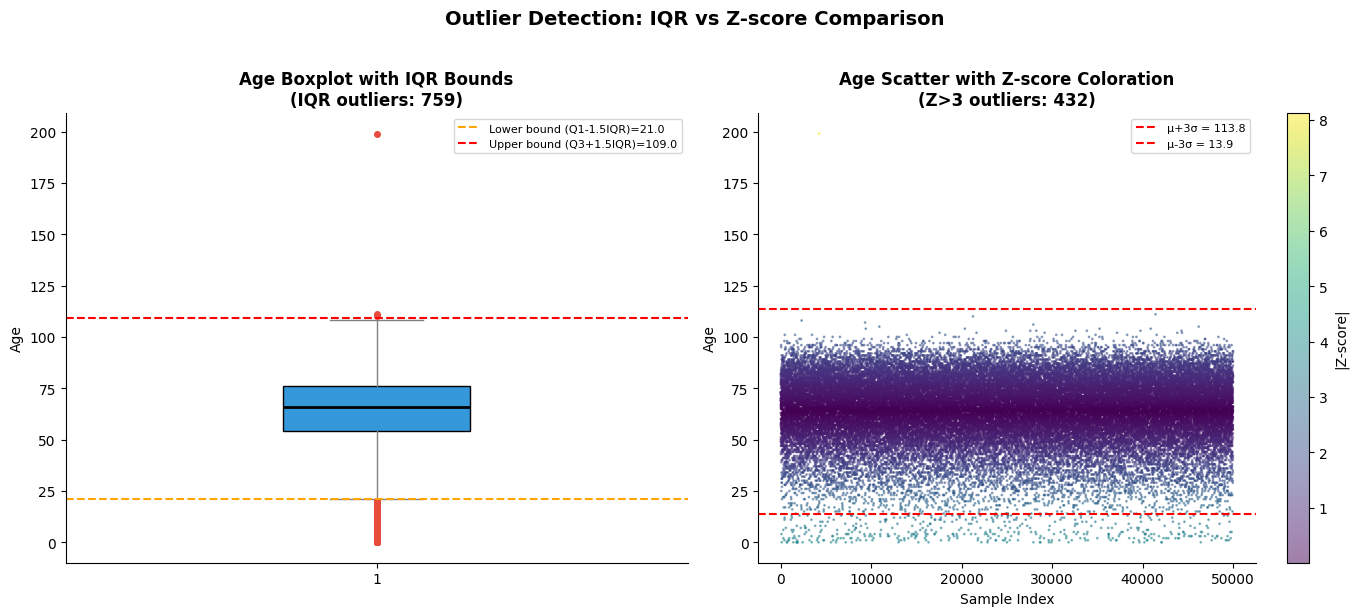

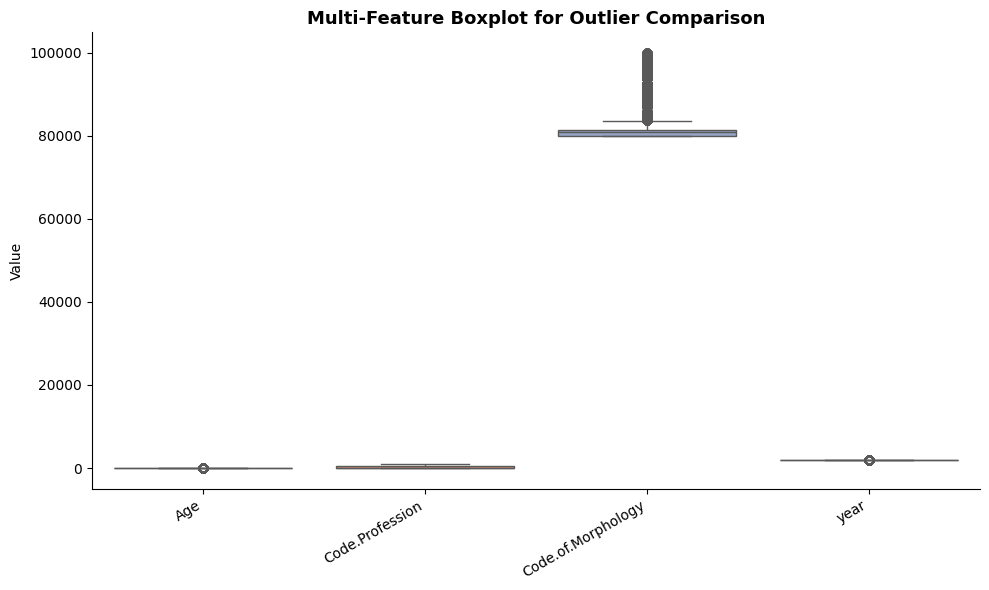

In [11]:

# 图 4a: IQR 方法的箱线图
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Age 箱线图 (IQR 标注)
if 'Age' in df.columns:
    age_data = df['Age'].dropna()
    if len(age_data) > 50000:
        age_data = age_data.sample(50000, random_state=42)

    q1 = age_data.quantile(0.25)
    q3 = age_data.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    bp = axes[0].boxplot(age_data, vert=True, patch_artist=True, widths=0.3)
    bp['boxes'][0].set_facecolor('#3498db')
    bp['whiskers'][0].set_color('gray')
    bp['whiskers'][1].set_color('gray')
    bp['caps'][0].set_color('gray')
    bp['caps'][1].set_color('gray')
    bp['medians'][0].set_color('black')
    bp['medians'][0].set_linewidth(2)
    bp['fliers'][0].set_markerfacecolor('#e74c3c')
    bp['fliers'][0].set_markeredgecolor('#e74c3c')
    bp['fliers'][0].set_markersize(4)

    axes[0].axhline(y=lower, color='orange', linestyle='--', linewidth=1.5, label=f'Lower bound (Q1-1.5IQR)={lower:.1f}')
    axes[0].axhline(y=upper, color='red', linestyle='--', linewidth=1.5, label=f'Upper bound (Q3+1.5IQR)={upper:.1f}')
    axes[0].set_title(f'Age Boxplot with IQR Bounds\n(IQR outliers: {len(age_data[(age_data < lower) | (age_data > upper)]):,})',
                      fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Age')
    axes[0].legend(fontsize=8)
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)

# Z-score 可视化
if 'Age' in df.columns:
    z_scores = np.abs((age_data - age_data.mean()) / age_data.std())

    axes[1].scatter(range(len(age_data)), age_data.values, c=z_scores.values,
                    cmap='viridis', alpha=0.5, s=1)
    axes[1].axhline(y=age_data.mean() + 3 * age_data.std(), color='red', linestyle='--',
                    linewidth=1.5, label=f'μ+3σ = {age_data.mean() + 3 * age_data.std():.1f}')
    axes[1].axhline(y=age_data.mean() - 3 * age_data.std(), color='red', linestyle='--',
                    linewidth=1.5, label=f'μ-3σ = {age_data.mean() - 3 * age_data.std():.1f}')
    axes[1].set_title(f'Age Scatter with Z-score Coloration\n(Z>3 outliers: {len(z_scores[z_scores > 3]):,})',
                      fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Sample Index')
    axes[1].set_ylabel('Age')
    cbar = plt.colorbar(axes[1].collections[0], ax=axes[1], label='|Z-score|')
    axes[1].legend(fontsize=8)
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)

plt.suptitle('Outlier Detection: IQR vs Z-score Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "04a_outlier_iqr_vs_zscore.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 04a_outlier_iqr_vs_zscore.png → IQR与Z-score离群值对比图已保存")

# 图 4b: 多变量箱线图
fig, ax = plt.subplots(figsize=(10, 6))
plot_cols = [c for c in numeric_features if c in df.columns][:5]  # 最多5个
plot_data = df[plot_cols].dropna()
if len(plot_data) > 30000:
    plot_data = plot_data.sample(30000, random_state=42)

plot_data_melted = plot_data.melt(var_name='Feature', value_name='Value')
sns.boxplot(data=plot_data_melted, x='Feature', y='Value', hue='Feature', palette='Set2', ax=ax, legend=False)
ax.set_title('Multi-Feature Boxplot for Outlier Comparison', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "04b_multifeature_boxplot.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 04b_multifeature_boxplot.png → 多变量箱线图已保存")

